# Cohort dating summary

Per-cohort QC of chronumental's predicted dates. For each `(segment, subtype, cohort)` combination the pipeline produced a `_dates.tsv`, this notebook reports the leaf residual against the reported `collection_date`, plots inferred vs reported dates for the leaves, and shows the distribution of inferred dates across every node (leaves + internal).

Driven by `rule cohort_dating_summary`. Inputs come from `snakemake.input`; the rendered HTML is written to `snakemake.output.html`.

In [1]:
import base64
import glob
import io
import os
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# Use the Snakemake namespace when invoked by `rule cohort_dating_summary`;
# fall back to repo-root discovery when running the notebook directly
# (e.g. via `jupyter nbconvert --execute --inplace`). nbconvert sets the
# kernel cwd to the notebook directory, so we walk up to the directory
# that contains `Snakefile` before resolving relative paths.
try:
    dates_paths = sorted(snakemake.input.dates)
    metadata_path = snakemake.input.metadata
    output_html = snakemake.output.html
except NameError:
    here = Path(os.getcwd()).resolve()
    repo_root = next(
        (p for p in [here, *here.parents] if (p / 'Snakefile').exists()),
        here,
    )
    dates_paths = sorted(glob.glob(str(repo_root / 'results/*/*/cohort_trees/*_dates.tsv')))
    metadata_path = str(repo_root / 'results/combined_metadata_augmented.csv')
    output_html = str(repo_root / 'results/cohort_dating_summary.html')


def parse_path(path):
    """results/HA/H1/cohort_trees/H1N1_human_post2012_dates.tsv -> ('HA', 'H1', 'H1N1_human_post2012')."""
    p = Path(path)
    parts = p.parts
    segment = parts[-4]
    subtype = parts[-3]
    cohort = p.name[: -len('_dates.tsv')]
    return segment, subtype, cohort


print(f'Found {len(dates_paths)} cohort dating outputs')
for path in dates_paths:
    print(f'  {path}')

Found 3 cohort dating outputs
  /fh/fast/matsen_e/hhaddox/2025/flu-usher/results/HA/H1/cohort_trees/H1N1_human_post2012_dates.tsv
  /fh/fast/matsen_e/hhaddox/2025/flu-usher/results/HA/H3/cohort_trees/H3N2_human_post2004_dates.tsv
  /fh/fast/matsen_e/hhaddox/2025/flu-usher/results/HA/H5/cohort_trees/H5_avian_all_dates.tsv


In [2]:
meta = pd.read_csv(metadata_path, usecols=['isolate_id', 'collection_date'])
meta['reported_date'] = pd.to_datetime(meta['collection_date'], format='%Y-%m-%d', errors='coerce')
meta = meta.dropna(subset=['reported_date'])[['isolate_id', 'reported_date']]
print(f'Metadata rows with full YYYY-MM-DD dates: {len(meta)}')

Metadata rows with full YYYY-MM-DD dates: 463589


In [3]:
cohort_data = {}
summary_rows = []

for path in dates_paths:
    segment, subtype, cohort = parse_path(path)
    pred = pd.read_csv(path, sep='\t')
    pred['predicted_date'] = pd.to_datetime(pred['predicted_date'])

    leaves = pred.merge(meta, left_on='strain', right_on='isolate_id', how='inner')
    leaves['residual_days'] = (leaves['predicted_date'] - leaves['reported_date']).dt.total_seconds() / 86400.0
    leaves['abs_residual_days'] = leaves['residual_days'].abs()

    cohort_data[(segment, subtype, cohort)] = {'all_nodes': pred, 'leaves': leaves}

    summary_rows.append({
        'segment': segment,
        'subtype': subtype,
        'cohort': cohort,
        'n_total_nodes': len(pred),
        'n_leaves_validated': len(leaves),
        'median_abs_residual_days': leaves['abs_residual_days'].median() if len(leaves) else np.nan,
        'mean_abs_residual_days': leaves['abs_residual_days'].mean() if len(leaves) else np.nan,
        'p90_abs_residual_days': leaves['abs_residual_days'].quantile(0.9) if len(leaves) else np.nan,
        'max_abs_residual_days': leaves['abs_residual_days'].max() if len(leaves) else np.nan,
        'frac_within_30d': (leaves['abs_residual_days'] <= 30).mean() if len(leaves) else np.nan,
        'frac_within_365d': (leaves['abs_residual_days'] <= 365).mean() if len(leaves) else np.nan,
        'earliest_inferred_date': pred['predicted_date'].min().date().isoformat(),
        'latest_inferred_date': pred['predicted_date'].max().date().isoformat(),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,segment,subtype,cohort,n_total_nodes,n_leaves_validated,median_abs_residual_days,mean_abs_residual_days,p90_abs_residual_days,max_abs_residual_days,frac_within_30d,frac_within_365d,earliest_inferred_date,latest_inferred_date
0,HA,H1,H1N1_human_post2012,83879,65156,6.637116,6.689254,6.779799,2559.728836,0.999647,0.999923,1919-04-10,2025-11-28
1,HA,H3,H3N2_human_post2004,90694,70271,3.196615,3.212868,3.333898,2185.387478,0.999687,0.999957,1949-02-09,2025-11-18
2,HA,H5,H5_avian_all,23088,16200,16.049927,26.977461,57.259750,26183.706282,0.659938,0.999815,1839-04-05,2025-06-28


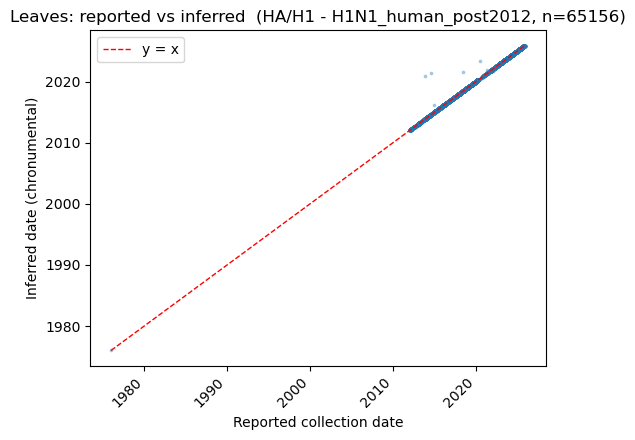

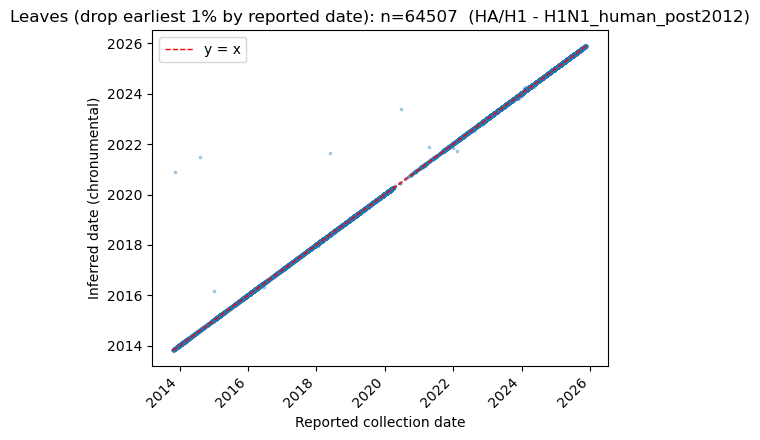

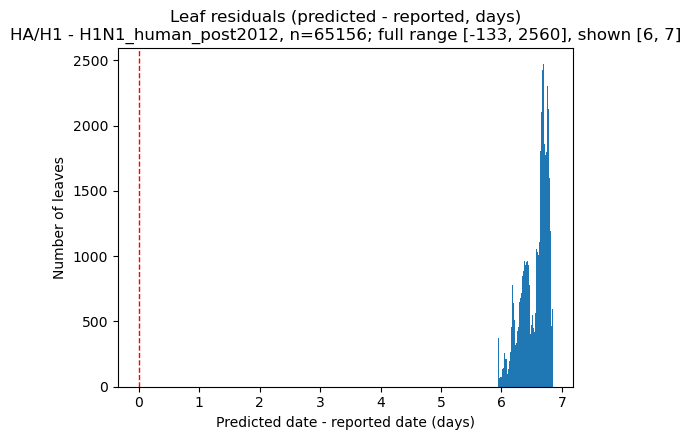

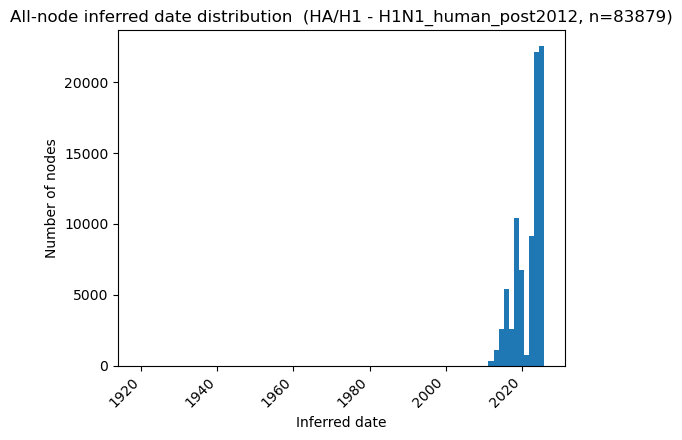

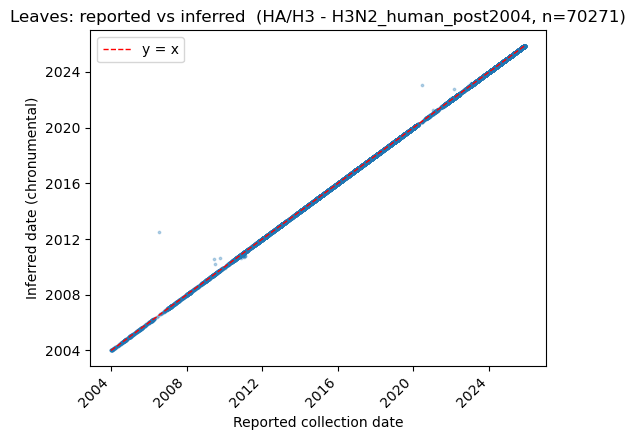

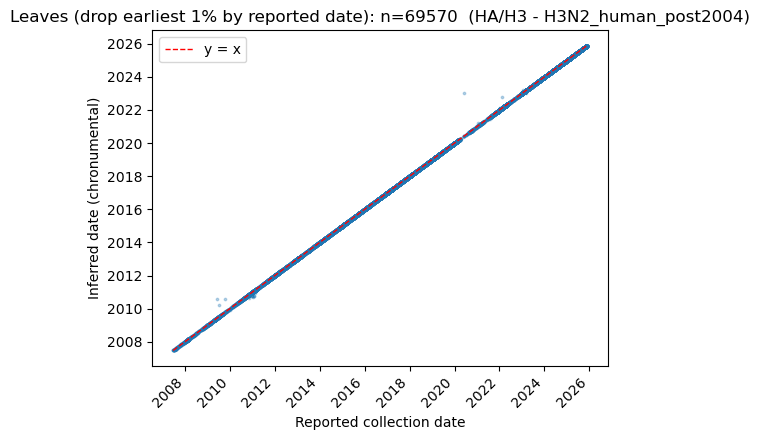

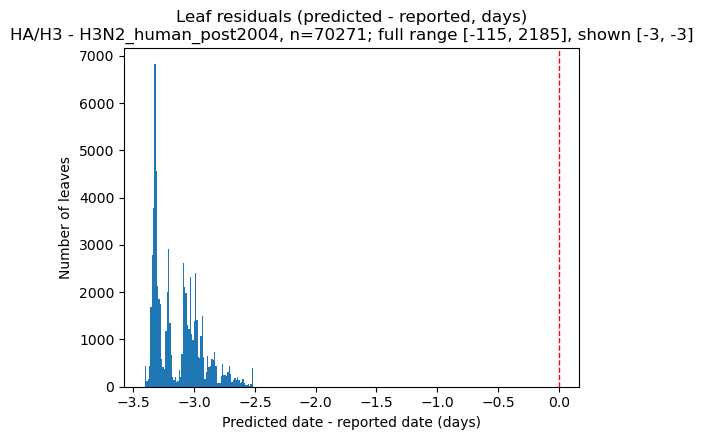

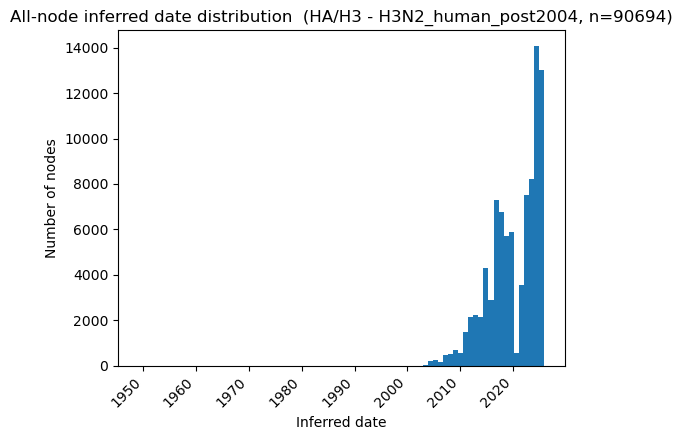

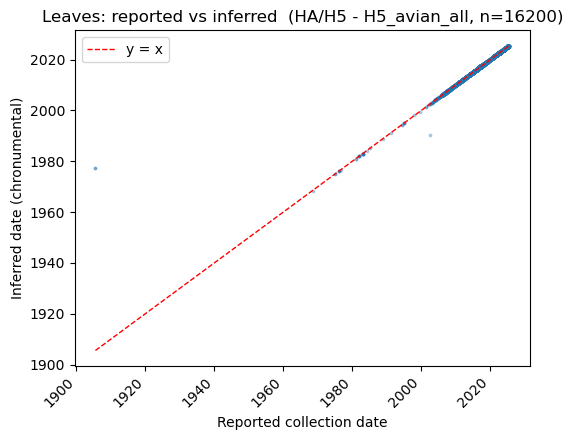

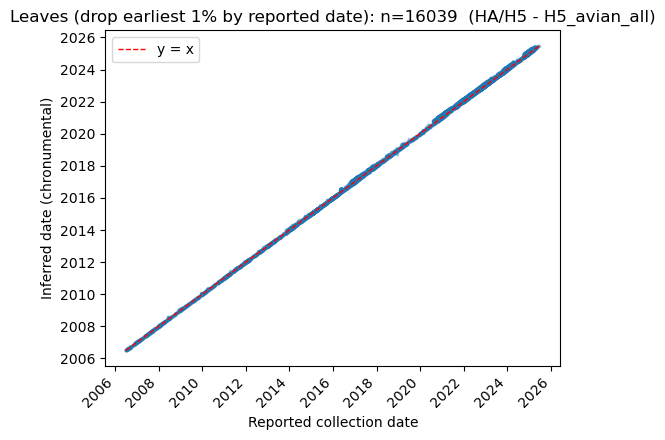

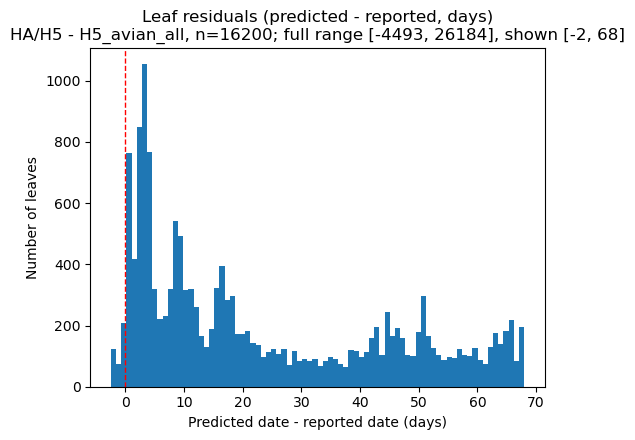

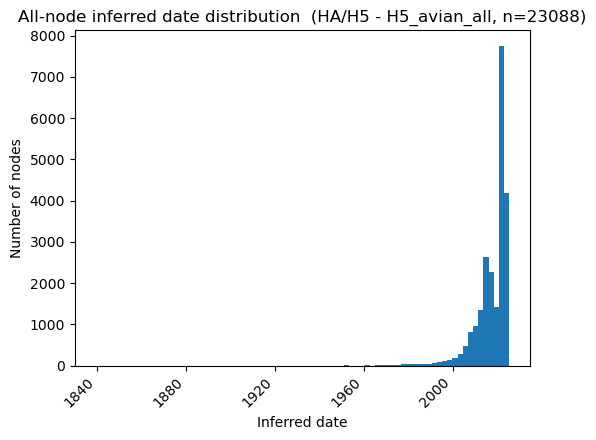

In [4]:
plot_figs = {}

# Trim the earliest 1% of leaves (by reported date) for the zoomed scatter,
# so the 1839-style outlier dates don't squash the bulk of the data into a
# tiny corner of the plot.
ZOOM_TRIM_FRACTION = 0.01

for key in sorted(cohort_data.keys()):
    segment, subtype, cohort = key
    label = f'{segment}/{subtype} - {cohort}'
    leaves = cohort_data[key]['leaves']
    all_nodes = cohort_data[key]['all_nodes']

    fig_s, ax_s = plt.subplots(figsize=(5.5, 4.5))
    if len(leaves):
        ax_s.scatter(leaves['reported_date'], leaves['predicted_date'], s=3, alpha=0.3)
        lo = min(leaves['reported_date'].min(), leaves['predicted_date'].min())
        hi = max(leaves['reported_date'].max(), leaves['predicted_date'].max())
        ax_s.plot([lo, hi], [lo, hi], 'r--', lw=1, label='y = x')
        ax_s.legend(loc='upper left')
    ax_s.set_xlabel('Reported collection date')
    ax_s.set_ylabel('Inferred date (chronumental)')
    ax_s.set_title(f'Leaves: reported vs inferred  ({label}, n={len(leaves)})')
    ax_s.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax_s.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax_s.yaxis.set_major_locator(mdates.AutoDateLocator())
    ax_s.yaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax_s.get_xticklabels(), rotation=45, ha='right')
    fig_s.tight_layout()

    fig_z, ax_z = plt.subplots(figsize=(5.5, 4.5))
    n_zoom = 0
    pct = int(round(ZOOM_TRIM_FRACTION * 100))
    if len(leaves):
        cutoff = leaves['reported_date'].quantile(ZOOM_TRIM_FRACTION)
        zoomed = leaves[leaves['reported_date'] >= cutoff]
        n_zoom = len(zoomed)
        if len(zoomed):
            ax_z.scatter(zoomed['reported_date'], zoomed['predicted_date'], s=3, alpha=0.3)
            lo = min(zoomed['reported_date'].min(), zoomed['predicted_date'].min())
            hi = max(zoomed['reported_date'].max(), zoomed['predicted_date'].max())
            ax_z.plot([lo, hi], [lo, hi], 'r--', lw=1, label='y = x')
            ax_z.legend(loc='upper left')
    ax_z.set_xlabel('Reported collection date')
    ax_z.set_ylabel('Inferred date (chronumental)')
    ax_z.set_title(f'Leaves (drop earliest {pct}% by reported date): n={n_zoom}  ({label})')
    ax_z.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax_z.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax_z.yaxis.set_major_locator(mdates.AutoDateLocator())
    ax_z.yaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax_z.get_xticklabels(), rotation=45, ha='right')
    fig_z.tight_layout()

    fig_r, ax_r = plt.subplots(figsize=(5.5, 4.5))
    if len(leaves):
        residuals = leaves['residual_days'].to_numpy()
        # Clip the visible range to the central 99% so a few huge outliers
        # don't blow out the bin width and make the bulk distribution
        # unreadable. Full range is reported in the title.
        lo_q, hi_q = np.quantile(residuals, [0.005, 0.995])
        if lo_q == hi_q:
            lo_q, hi_q = lo_q - 1, hi_q + 1
        ax_r.hist(np.clip(residuals, lo_q, hi_q), bins=80)
        ax_r.axvline(0, color='red', lw=1, ls='--')
        full_lo, full_hi = residuals.min(), residuals.max()
        title = (f'Leaf residuals (predicted - reported, days)\n'
                 f'{label}, n={len(leaves)}; full range [{full_lo:.0f}, {full_hi:.0f}], '
                 f'shown [{lo_q:.0f}, {hi_q:.0f}]')
    else:
        title = f'Leaf residuals (no leaves)  ({label})'
    ax_r.set_xlabel('Predicted date - reported date (days)')
    ax_r.set_ylabel('Number of leaves')
    ax_r.set_title(title)
    fig_r.tight_layout()

    fig_h, ax_h = plt.subplots(figsize=(5.5, 4.5))
    dates_num = mdates.date2num(all_nodes['predicted_date'])
    ax_h.hist(dates_num, bins=80)
    ax_h.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax_h.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax_h.set_xlabel('Inferred date')
    ax_h.set_ylabel('Number of nodes')
    ax_h.set_title(f'All-node inferred date distribution  ({label}, n={len(all_nodes)})')
    plt.setp(ax_h.get_xticklabels(), rotation=45, ha='right')
    fig_h.tight_layout()

    plot_figs[key] = (fig_s, fig_z, fig_r, fig_h)

plt.show()

In [5]:
def fig_to_b64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=120, bbox_inches='tight')
    plt.close(fig)
    return base64.b64encode(buf.getvalue()).decode('ascii')


html = [
    '<!DOCTYPE html>',
    "<html><head><meta charset='utf-8'><title>Cohort dating summary</title>",
    '<style>',
    'body{font-family:sans-serif;max-width:1300px;margin:20px auto;padding:0 20px;}',
    'table{border-collapse:collapse;font-size:13px;}',
    'td,th{border:1px solid #ccc;padding:4px 8px;text-align:right;}',
    'th{background:#eee;}',
    'img{max-width:100%;height:auto;}',
    'h2{margin-top:30px;border-bottom:1px solid #ccc;padding-bottom:4px;}',
    '.plots{display:flex;gap:20px;flex-wrap:wrap;}',
    '.plots>div{flex:1 1 520px;min-width:0;}',
    '</style></head><body>',
    '<h1>Cohort dating summary</h1>',
    '<p>Per-cohort validation of chronumental-inferred dates. The summary table reports leaf residuals (predicted minus reported, in days) for each cohort tree. The per-cohort sections show, in order: a scatter of reported vs inferred dates for leaves; the same scatter with the earliest 1% of points trimmed for a zoomed view; the leaf residual distribution (predicted minus reported); and a histogram of inferred dates across every node (leaves and internal).</p>',
    '<h2>Per-cohort summary</h2>',
    summary_df.round(2).to_html(index=False),
]

for key in sorted(plot_figs.keys()):
    segment, subtype, cohort = key
    fig_s, fig_z, fig_r, fig_h = plot_figs[key]
    html += [
        f'<h2>{segment} / {subtype} - {cohort}</h2>',
        "<div class='plots'>",
        f"<div><img src='data:image/png;base64,{fig_to_b64(fig_s)}'/></div>",
        f"<div><img src='data:image/png;base64,{fig_to_b64(fig_z)}'/></div>",
        f"<div><img src='data:image/png;base64,{fig_to_b64(fig_r)}'/></div>",
        f"<div><img src='data:image/png;base64,{fig_to_b64(fig_h)}'/></div>",
        '</div>',
    ]

html.append('</body></html>')
Path(output_html).write_text('\n'.join(html))
print(f'Wrote {output_html}')

Wrote /fh/fast/matsen_e/hhaddox/2025/flu-usher/results/cohort_dating_summary.html
